# 3-D Benchmark — Prompt U-Net (multi-mode) vs nnInteractive

**Combined runner + results notebook.**

All P-UNet **modes** are evaluated on the **exact same initial prompt** per run.  
nnInteractive is run:
- once as a **baseline** (initial prompt only, no IFL)
- once **paired** with every IFL-enabled P-UNet mode, using the *same* `user_interacts_idx`

```
Example: modes = ['ssf', 'ifl', 'ifl_ssf']
  P-UNet ssf     —  compare with nn_baseline   (n_inter=0)
  P-UNet ifl     —  compare with nn+ifl         (n_inter = same as IFL produced)
  P-UNet ifl_ssf —  compare with nn+ifl_ssf     (n_inter = same as IFL+SSF produced)
```

| Workflow |
|---|
| **§1** Configure paths & parameters |
| **§2** Run the benchmark *(skip if loading saved results)* |
| **§3** Load results & analyse |
| **§4** Export flat CSV |

---
## §1 — Configuration

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

In [1]:
import sys, os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

P_UNET_MODELS = [
    os.path.join(PROJECT_ROOT, 'training', 'p_unet_332.keras'),
]
NN_MODEL_DIR = None

NPZ_PATHS = [
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'TotalSeg_mri.npz'),
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'FLARE_2022.npz'),
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'han_seg_ct.npz'),
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'han_seg_mri.npz'),
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'SegRap2023.npz'),
    os.path.join(PROJECT_ROOT, 'data', 'test_data', 'HCCTase_ceCT.npz')
]

# Modes: all evaluated on the SAME initial prompt per run
# Each IFL mode => one extra paired nnInteractive run
MODES = ['ssf', 'none', 'ifl_ssf']

RUNS_PER_VOL      = 4
MODALITY          = None
OUTPUT_THRESHOLD  = 0.5
SSF_THRESHOLD     = 0.05
GT_DICE_THRESHOLD = 0.65
BATCH_SIZE        = 6
WINDOW            = 12
MIN_PROMPT_PIXELS = 50
NN_DEVICE         = None
MAX_VOLUMES       = None
OUTPUT_DIR        = os.getcwd()

print('Config OK')
print(f'  P-UNet modes : {MODES}')
print(f'  nnInteractive: baseline + one paired run per IFL mode')
print(f'  Datasets     : {[os.path.basename(p) for p in NPZ_PATHS]}')

Config OK
  P-UNet modes : ['ssf', 'none', 'ifl_ssf']
  nnInteractive: baseline + one paired run per IFL mode
  Datasets     : ['TotalSeg_mri.npz', 'FLARE_2022.npz', 'han_seg_ct.npz', 'han_seg_mri.npz', 'SegRap2023.npz', 'HCCTase_ceCT.npz']


---
## §2 — Run Benchmark

> Skip if you already have a `.pkl` file.

In [ ]:
from inference.ssf import ConfidenceDropStrategy
from evaluation.benchmark_nninteractive.benchmark_3d import run_benchmark

all_records = []
for p_model in P_UNET_MODELS:
    print(f'\n--- {os.path.basename(p_model)} ---')
    records = run_benchmark(
        npz_paths         = NPZ_PATHS,
        p_unet_model      = p_model,
        nn_model_dir      = NN_MODEL_DIR,
        runs_per_vol      = RUNS_PER_VOL,
        modes             = MODES,
        modality          = MODALITY,
        output_threshold  = OUTPUT_THRESHOLD,
        ssf_strategy      = ConfidenceDropStrategy(SSF_THRESHOLD),
        gt_dice_threshold = GT_DICE_THRESHOLD,
        batch_size        = BATCH_SIZE,
        window            = WINDOW,
        max_volumes       = MAX_VOLUMES,
        output_dir        = OUTPUT_DIR,
        nn_device         = NN_DEVICE,
        verbose           = True,
        return_predictions= False,
    )
    all_records.extend(records)

print(f'\nDone — {len(all_records)} runs collected.')

---
## §3 — Load & Analyse Results

In [2]:
import pickle, os
import pandas as pd

# Option A: use results already in memory
# records = all_records

# Option B: load newest pkl
# pkl_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, 'results_*.pkl')))
# if not pkl_files:
#     raise FileNotFoundError(f'No results .pkl in {OUTPUT_DIR}')
# LOAD_PATH = pkl_files[-1]

LOAD_PATH = "results_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_135822.pkl"


print(f'Loading: {LOAD_PATH}')
with open(LOAD_PATH, 'rb') as f:
    records = pickle.load(f)

MODES_EVALUATED = records[0]['modes_evaluated']
NN_KEYS         = sorted({k for r in records for k in r.get('nn_results', {})})
DATASETS        = sorted(set(r['dataset_name'] for r in records))
IFL_MODES       = [m for m in MODES_EVALUATED if 'ifl' in m]

print(f'Loaded {len(records)} runs')
print(f'P-UNet modes : {MODES_EVALUATED}')
print(f'nn_results   : {NN_KEYS}  (baseline + paired with {IFL_MODES})')
print(f'Datasets     : {DATASETS}')

Loading: results_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_135822.pkl
Loaded 1432 runs
P-UNet modes : ['ssf', 'none', 'ifl_ssf']
nn_results   : ['baseline', 'ifl_ssf']  (baseline + paired with ['ifl_ssf'])
Datasets     : ['FLARE_2022', 'HCCTase_ceCT', 'SegRap2023', 'TotalSeg_mri', 'han_seg_ct', 'han_seg_mri']


In [3]:
# n_interactions — IFL corrections only, excluding the initial prompt.
# Both P-UNet and nnInteractive use the same convention.
rows_long = []
for r in records:
    base = {
        'volume_id'   : r['volume_id'],
        'pid'         : r['pid'],
        'run_idx'     : r['run_idx'],
        'dataset_name': r['dataset_name'],
        'modality'    : r['modality'],
        'prompt_axis' : r['prompt_axis'],
        'roi_slices'  : r.get('roi_slices'),   # non-empty slices of ROI along prompt_axis
        'roi_voxels'  : r.get('roi_voxels'),   # total foreground voxels of ROI
    }
    for mode, md in r.get('per_mode', {}).items():
        paired = mode if 'ifl' in mode else 'baseline'
        rows_long.append({
            **base,
            'model'         : f'P-UNet [{mode}]',
            'mode'          : mode,
            'is_nn'         : False,
            'paired_nn_key' : paired,
            'vol_dice'      : md['vol_dice'],
            'window_dice'   : md['window_dice'],
            'time_s'        : md['time_s'],
            'n_interactions': md.get('n_interactions'),
            'num_slices'    : md.get('num_slices_evaluated'),
        })
    for nn_key, nn_md in r.get('nn_results', {}).items():
        label = 'nn_baseline' if nn_key == 'baseline' else f'nn+{nn_key}'
        rows_long.append({
            **base,
            'model'         : label,
            'mode'          : nn_key,
            'is_nn'         : True,
            'paired_nn_key' : nn_key,
            'vol_dice'      : nn_md['vol_dice'],
            'window_dice'   : nn_md['window_dice'],
            'time_s'        : nn_md['time_s'],
            'n_interactions': nn_md.get('n_interactions'),
            'num_slices'    : None,
        })

df_long  = pd.DataFrame(rows_long)
df_punet = df_long[~df_long['is_nn']].copy()
df_nn    = df_long[df_long['is_nn']].copy()

PUNET_LABELS = [f'P-UNet [{m}]' for m in MODES_EVALUATED]
NN_LABELS    = ['nn_baseline'] + [f'nn+{m}' for m in IFL_MODES]
ALL_LABELS   = PUNET_LABELS + NN_LABELS

PALETTE = {
    'P-UNet [ssf]'    : '#4A90D9',
    'P-UNet [ifl]'    : '#50C878',
    'P-UNet [ifl_ssf]': '#9B59B6',
    'P-UNet [none]'   : '#BDC3C7',
    'nn_baseline'     : '#E87040',
    'nn+ifl'          : '#D4550F',
    'nn+ifl_ssf'      : '#A03010',
}
DEFAULT_COLOR = '#888888'

print(f'Long df: {len(df_long)} rows')
print(f'P-UNet labels: {PUNET_LABELS}')
print(f'NN labels    : {NN_LABELS}')
df_long.head()

Long df: 7160 rows
P-UNet labels: ['P-UNet [ssf]', 'P-UNet [none]', 'P-UNet [ifl_ssf]']
NN labels    : ['nn_baseline', 'nn+ifl_ssf']


,volume_id,pid,run_idx,dataset_name,modality,prompt_axis,roi_slices,roi_voxels,model,mode,is_nn,paired_nn_key,vol_dice,window_dice,time_s,n_interactions,num_slices
0,TotalSeg_mri__s0001,s0001,0,TotalSeg_mri,MRI,0,164,1690058,P-UNet [ssf],ssf,False,baseline,0.836263,0.963564,4.632144,NaN,164.0
1,TotalSeg_mri__s0001,s0001,0,TotalSeg_mri,MRI,0,164,1690058,P-UNet [none],none,False,baseline,0.806319,0.963564,3.490304,NaN,164.0
2,TotalSeg_mri__s0001,s0001,0,TotalSeg_mri,MRI,0,164,1690058,P-UNet [ifl_ssf],ifl_ssf,False,ifl_ssf,0.883489,0.963564,2.454340,7.0,164.0
3,TotalSeg_mri__s0001,s0001,0,TotalSeg_mri,MRI,0,164,1690058,nn_baseline,baseline,True,baseline,0.952308,0.951635,2.539507,0.0,NaN
4,TotalSeg_mri__s0001,s0001,0,TotalSeg_mri,MRI,0,164,1690058,nn+ifl_ssf,ifl_ssf,True,ifl_ssf,0.946999,0.942584,2.149115,7.0,NaN


### 3.1 — Overall summary

In [4]:
def _fmt(s):
    s = pd.Series(s).dropna()
    return (
        f'{s.mean():.3f} ± {s.std():.3f}  '
        f'[med={s.median():.3f}  min={s.min():.3f}  max={s.max():.3f}  n={len(s)}]'
        if len(s) else 'N/A'
    )

print(f"{'='*78}")
print(f"  SUMMARY   n_runs={len(records)}")
print(f"{'='*78}")

for label in ALL_LABELS:
    sub = df_long[df_long['model'] == label]
    if sub.empty:
        continue
    print(f"\n  {label}")
    print(f"    Vol Dice    : {_fmt(sub['vol_dice'])}")
    print(f"    Window Dice : {_fmt(sub['window_dice'])}")
    print(f"    Time (s)    : {_fmt(sub['time_s'])}")
    n_inter = sub['n_interactions'].dropna()
    if not n_inter.empty:
        total = int(n_inter.sum())
        print(f"    IFL corr.   : {_fmt(n_inter)}  (excl. initial)  total={total}")

print(f"\n{'='*78}")

  SUMMARY   n_runs=1432

  P-UNet [ssf]
    Vol Dice    : 0.691 ± 0.202  [med=0.743  min=0.003  max=1.000  n=1432]
    Window Dice : 0.752 ± 0.196  [med=0.808  min=0.077  max=1.000  n=1432]
    Time (s)    : 0.912 ± 0.720  [med=0.705  min=0.035  max=8.299  n=1432]

  P-UNet [none]
    Vol Dice    : 0.667 ± 0.204  [med=0.720  min=0.003  max=1.000  n=1432]
    Window Dice : 0.745 ± 0.196  [med=0.797  min=0.077  max=1.000  n=1432]
    Time (s)    : 0.864 ± 0.650  [med=0.675  min=0.035  max=5.609  n=1432]

  P-UNet [ifl_ssf]
    Vol Dice    : 0.881 ± 0.044  [med=0.881  min=0.000  max=1.000  n=1432]
    Window Dice : 0.899 ± 0.045  [med=0.896  min=0.594  max=1.000  n=1432]
    Time (s)    : 0.969 ± 0.642  [med=0.783  min=0.037  max=4.319  n=1432]
    IFL corr.   : 8.265 ± 13.332  [med=5.000  min=0.000  max=174.000  n=1432]  (excl. initial)  total=11836

  nn_baseline
    Vol Dice    : 0.741 ± 0.191  [med=0.798  min=0.038  max=1.000  n=1432]
    Window Dice : 0.757 ± 0.197  [med=0.822  min=0

### 3.2 — Per-Dataset Bar Charts

Main result figures comparing Prompt U-Net against nnInteractive on 3D volumetric segmentation. Both volumetric Dice and window Dice ($\pm W$) are shown. Two pairwise comparisons, each on the **same initial prompt** per run:

- **SSF (zero interactions)**: P-UNet [ssf] vs nn_baseline — both use only the initial prompt.
- **IFL + SSF (matched interactions)**: P-UNet [ifl_ssf] vs nn+ifl — both receive the **same** IFL corrections (nnInteractive has no SSF).

Han-Seg CT and MRI are merged into a single bar, matching the 2D benchmark.
Style matches the 2D benchmark figure in Section~\ref{subsec:2d-results}.

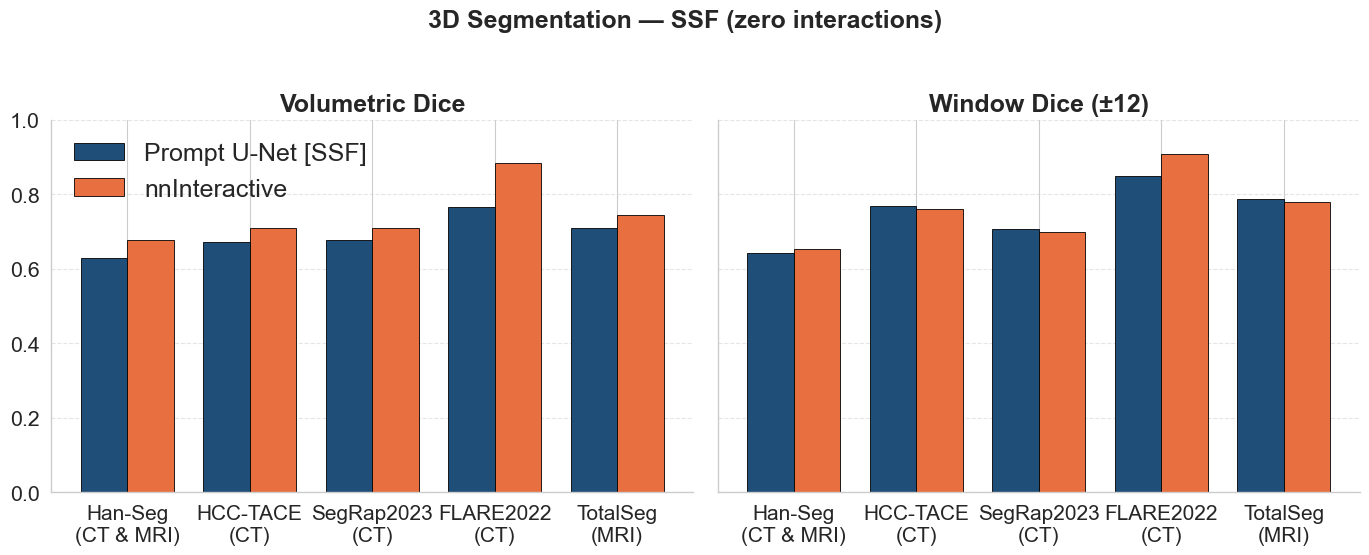

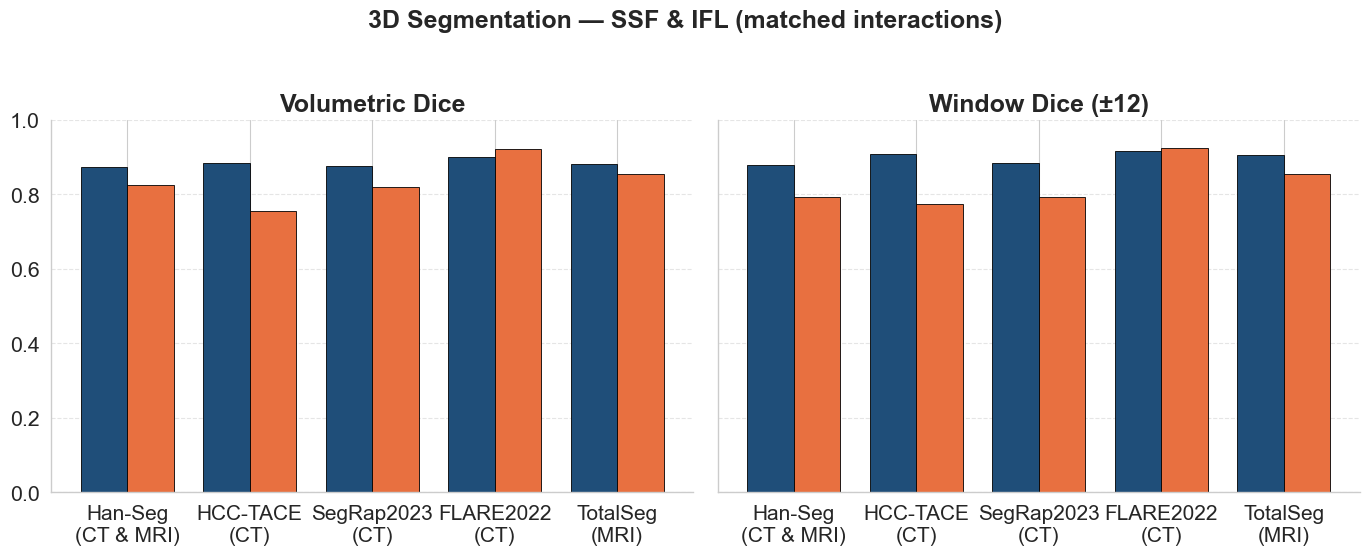

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os as _os

sns.set_theme(style="whitegrid", context="paper", font_scale=1.75)

# ── Dataset grouping ─────────────────────────────────────────────────────────
DATASET_GROUP = {
    "FLARE_2022":   "FLARE_2022",
    "TotalSeg_mri": "TotalSeg_mri",
    "han_seg_ct":   "Han-Seg",
    "han_seg_mri":  "Han-Seg",
    "SegRap2023":   "SegRap2023",
    "HCCTase_ceCT": "HCCTase_ceCT",
}

DS_ORDER = ["Han-Seg", "HCCTase_ceCT", "SegRap2023", "FLARE_2022", "TotalSeg_mri"]

DATASET_DISPLAY = {
    "FLARE_2022":   "FLARE2022\n(CT)",
    "Han-Seg":      "Han-Seg\n(CT & MRI)",
    "HCCTase_ceCT": "HCC-TACE\n(CT)",
    "SegRap2023":   "SegRap2023\n(CT)",
    "TotalSeg_mri": "TotalSeg\n(MRI)",
}

df_long["ds_group"] = df_long["dataset_name"].map(DATASET_GROUP)

NN_IFL_KEY = (
    "nn+ifl_ssf" if "nn+ifl_ssf" in df_long["model"].values
    else "nn+ifl" if "nn+ifl" in df_long["model"].values
    else None
)

if NN_IFL_KEY is None:
    raise KeyError("Neither 'nn+ifl_ssf' nor 'nn+ifl' found in df_long.")

MODEL_DISPLAY = {
    "P-UNet [ssf]":      "Prompt U-Net [SSF]",
    "P-UNet [ifl_ssf]":  "Prompt U-Net [SSF & IFL]",
    "nn_baseline":       "nnInteractive",
    NN_IFL_KEY:          "nnInteractive [IFL]",
}

PUNET_COLOR = "#1f4e79"
NN_COLOR    = "#E87040"

COMPARISONS = [
    ("P-UNet [ssf]",     "nn_baseline", "ssf",     "SSF (zero interactions)"),
    ("P-UNet [ifl_ssf]", NN_IFL_KEY,    "ifl_ssf", "SSF & IFL (matched interactions)"),
]

METRICS = [
    ("vol_dice",    "Volumetric Dice"),
    ("window_dice", f"Window Dice (±{WINDOW})"),
]

for punet_label, nn_label, tag, desc in COMPARISONS:

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

    for ax_idx, (ax, (metric_col, metric_name)) in enumerate(zip(axes, METRICS)):

        punet_grouped = (
            df_long[df_long["model"] == punet_label]
            .groupby("ds_group")[metric_col].mean()
        )

        nn_grouped = (
            df_long[df_long["model"] == nn_label]
            .groupby("ds_group")[metric_col].mean()
        )

        punet_vals = [punet_grouped.get(ds, np.nan) for ds in DS_ORDER]
        nn_vals    = [nn_grouped.get(ds, np.nan) for ds in DS_ORDER]

        x = np.arange(len(DS_ORDER))
        width = 0.38

        ax.bar(
            x - width / 2, punet_vals,
            width=width,
            label=MODEL_DISPLAY[punet_label],
            color=PUNET_COLOR,
            edgecolor="black",
            linewidth=0.6,
        )

        ax.bar(
            x + width / 2, nn_vals,
            width=width,
            label=MODEL_DISPLAY[nn_label],
            color=NN_COLOR,
            edgecolor="black",
            linewidth=0.6,
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            [DATASET_DISPLAY[ds] for ds in DS_ORDER],
            ha="center",
            fontsize=13,
        )

        ax.set_ylim(0, 1.0)
        ax.set_title(metric_name, fontsize=18, weight="bold")
        ax.tick_params(axis='x', labelsize=15)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if tag == "ssf" and ax is axes[0]:
            ax.legend(frameon=False, fontsize=18, loc="upper left")

    axes[1].tick_params(axis="y", labelsize=13, labelleft=False)

    fig.suptitle(
        f"3D Segmentation — {desc}",
        fontsize=18,
        weight="bold",
        y=1.02,
    )

    plt.tight_layout()

    plt.savefig(
        _os.path.join(OUTPUT_DIR, f"dice_3d_{tag}.pdf"),
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [6]:
rows = []
for ds in DATASETS:
    ds_df = df_long[df_long['dataset_name'] == ds]
    
    # Calculate avg 2d slices evaluated for this dataset
    # (extracted from P-UNet rows where it is not null)
    ds_slices_mean = ds_df['num_slices'].dropna().mean()
    
    for label in ALL_LABELS:
        sub = ds_df[ds_df['model'] == label]
        if sub.empty:
            continue
        ni   = sub['n_interactions'].dropna()
        rows.append({
            'dataset'       : ds,
            'model'         : label,
            'n_runs'        : len(sub),
            'vol_mean'      : sub['vol_dice'].mean(),
            'vol_std'       : sub['vol_dice'].std(),
            'win_mean'      : sub['window_dice'].mean(),
            'win_std'       : sub['window_dice'].std(),
            'time_mean'     : sub['time_s'].mean(),
            'ifl_avg'       : ni.mean() if not ni.empty else None,
            'ifl_total'     : int(ni.sum()) if not ni.empty else None,
            'slices_mean'   : ds_slices_mean,
        })

ds_table = pd.DataFrame(rows)
ds_table['Vol Dice'] = ds_table.apply(lambda r: f"{r['vol_mean']:.3f} ±{r['vol_std']:.3f}", axis=1)
ds_table['Win Dice'] = ds_table.apply(lambda r: f"{r['win_mean']:.3f} ±{r['win_std']:.3f}", axis=1)
ds_table['Time (s)'] = ds_table['time_mean'].map(lambda x: f'{x:.1f}s')
ds_table['Avg IFL']  = ds_table['ifl_avg'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '—')
ds_table['Total IFL']= ds_table['ifl_total'].map(lambda x: str(x) if pd.notna(x) else '—')
ds_table['Avg Slices'] = ds_table['slices_mean'].map(lambda x: f'{x:.1f}' if pd.notna(x) else '—')

# Added Avg Slices to the display columns
display(ds_table[['dataset','model','n_runs','Vol Dice','Win Dice','Time (s)','Avg Slices','Avg IFL','Total IFL']].set_index(['dataset','model']))


n_runs      Vol Dice      Win Dice Time (s)  \
dataset      model                                                           
FLARE_2022   P-UNet [ssf]         200  0.767 ±0.171  0.849 ±0.148     0.9s   
             P-UNet [none]        200  0.743 ±0.181  0.847 ±0.149     0.8s   
             P-UNet [ifl_ssf]     200  0.900 ±0.031  0.917 ±0.044     0.9s   
             nn_baseline          200  0.884 ±0.116  0.909 ±0.072     0.8s   
             nn+ifl_ssf           200  0.921 ±0.054  0.926 ±0.052     0.9s   
HCCTase_ceCT P-UNet [ssf]         156  0.673 ±0.290  0.770 ±0.241     1.2s   
             P-UNet [none]        156  0.639 ±0.286  0.758 ±0.238     1.1s   
             P-UNet [ifl_ssf]     156  0.883 ±0.032  0.909 ±0.042     1.4s   
             nn_baseline          156  0.711 ±0.259  0.761 ±0.237     0.9s   
             nn+ifl_ssf           156  0.755 ±0.223  0.773 ±0.233     1.4s   
SegRap2023   P-UNet [ssf]         160  0.678 ±0.189  0.707 ±0.183     0.8s   
             P-UNet [none]        160  0.663 ±0.191  0.700 ±0.180     0.9s   
             P-UNet [ifl_ssf]     160  0.877 ±0.044  0.886 ±0.042     0.9s   
             nn_baseline          160  0.709 ±0.149  0.700 ±0.177     1.3s   
             nn+ifl_ssf           160  0.819 ±0.101  0.793 ±0.130     1.6s   
TotalSeg_mri P-UNet [ssf]         580  0.709 ±0.175  0.788 ±0.177     1.0s   
             P-UNet [none]        580  0.677 ±0.181  0.783 ±0.178     0.9s   
             P-UNet [ifl_ssf]     580  0.881 ±0.050  0.905 ±0.046     1.0s   
             nn_baseline          580  0.745 ±0.180  0.779 ±0.181     0.6s   
             nn+ifl_ssf           580  0.855 ±0.084  0.854 ±0.100     0.7s   
han_seg_ct   P-UNet [ssf]         168  0.645 ±0.187  0.671 ±0.174     0.8s   
             P-UNet [none]        168  0.638 ±0.189  0.665 ±0.172     0.9s   
             P-UNet [ifl_ssf]     168  0.868 ±0.041  0.872 ±0.042     0.8s   
             nn_baseline          168  0.687 ±0.180  0.676 ±0.196     1.1s   
             nn+ifl_ssf           168  0.819 ±0.108  0.782 ±0.140     1.5s   
han_seg_mri  P-UNet [ssf]         168  0.612 ±0.212  0.616 ±0.187     0.5s   
             P-UNet [none]        168  0.602 ±0.208  0.607 ±0.184     0.5s   
             P-UNet [ifl_ssf]     168  0.877 ±0.037  0.885 ±0.036     0.6s   
             nn_baseline          168  0.665 ±0.181  0.629 ±0.192     0.4s   
             nn+ifl_ssf           168  0.831 ±0.066  0.802 ±0.091     0.5s   

                              Avg Slices Avg IFL Total IFL  
dataset      model                                          
FLARE_2022   P-UNet [ssf]           88.8       —         —  
             P-UNet [none]          88.8       —         —  
             P-UNet [ifl_ssf]       88.8    5.02    1004.0  
             nn_baseline            88.8    0.00       0.0  
             nn+ifl_ssf             88.8    5.02    1004.0  
HCCTase_ceCT P-UNet [ssf]          112.9       —         —  
             P-UNet [none]         112.9       —         —  
             P-UNet [ifl_ssf]      112.9   21.81    3403.0  
             nn_baseline           112.9    0.00       0.0  
             nn+ifl_ssf            112.9   21.81    3403.0  
SegRap2023   P-UNet [ssf]           38.6       —         —  
             P-UNet [none]          38.6       —         —  
             P-UNet [ifl_ssf]       38.6    5.73     917.0  
             nn_baseline            38.6    0.00       0.0  
             nn+ifl_ssf             38.6    5.73     917.0  
TotalSeg_mri P-UNet [ssf]           72.5       —         —  
             P-UNet [none]          72.5       —         —  
             P-UNet [ifl_ssf]       72.5    7.11    4126.0  
             nn_baseline            72.5    0.00       0.0  
             nn+ifl_ssf             72.5    7.11    4126.0  
han_seg_ct   P-UNet [ssf]           36.0       —         —  
             P-UNet [none]          36.0       —         —  
             P-UNet [ifl_ssf]       36.0    6.23    1047.0  
         

In [7]:
# Dataset-level means (pooled over all runs):
#   Generalist  = all runs in FLARE_2022, TotalSeg_mri
#   Specialized = all runs in Han-Seg (CT+MRI), HCCTase_ceCT, SegRap2023

generalist_ds = ['FLARE_2022', 'TotalSeg_mri']
specialist_ds = ['han_seg_ct', 'han_seg_mri', 'HCCTase_ceCT', 'SegRap2023']

print(f"{'='*90}")
print("  DATASET-LEVEL AVERAGES  (pooled over all runs)")
print(f"{'='*90}")

for label in ALL_LABELS:
    sub = df_long[df_long['model'] == label]

    gen_vol  = sub[sub['dataset_name'].isin(generalist_ds)]['vol_dice'].mean()
    spec_vol = sub[sub['dataset_name'].isin(specialist_ds)]['vol_dice'].mean()
    
    gen_win  = sub[sub['dataset_name'].isin(generalist_ds)]['window_dice'].mean()
    spec_win = sub[sub['dataset_name'].isin(specialist_ds)]['window_dice'].mean()

    print(f"\n  {label}")
    print(f"    Generalist  (FLARE + TotalSeg) : Vol Dice = {gen_vol:.3f}  |  Win Dice = {gen_win:.3f}")
    print(f"    Specialized (HanSeg + HCC + SegRap): Vol Dice = {spec_vol:.3f}  |  Win Dice = {spec_win:.3f}")

print(f"\n{'='*90}")


  DATASET-LEVEL AVERAGES  (pooled over all runs)

  P-UNet [ssf]
    Generalist  (FLARE + TotalSeg) : Vol Dice = 0.724  |  Win Dice = 0.804
    Specialized (HanSeg + HCC + SegRap): Vol Dice = 0.651  |  Win Dice = 0.689

  P-UNet [none]
    Generalist  (FLARE + TotalSeg) : Vol Dice = 0.694  |  Win Dice = 0.799
    Specialized (HanSeg + HCC + SegRap): Vol Dice = 0.635  |  Win Dice = 0.681

  P-UNet [ifl_ssf]
    Generalist  (FLARE + TotalSeg) : Vol Dice = 0.886  |  Win Dice = 0.908
    Specialized (HanSeg + HCC + SegRap): Vol Dice = 0.876  |  Win Dice = 0.888

  nn_baseline
    Generalist  (FLARE + TotalSeg) : Vol Dice = 0.781  |  Win Dice = 0.812
    Specialized (HanSeg + HCC + SegRap): Vol Dice = 0.693  |  Win Dice = 0.690

  nn+ifl_ssf
    Generalist  (FLARE + TotalSeg) : Vol Dice = 0.872  |  Win Dice = 0.872
    Specialized (HanSeg + HCC + SegRap): Vol Dice = 0.807  |  Win Dice = 0.788



### 3.4 — Per-dataset volume size statistics

In [8]:
# One row per (volume_id, run_idx) — deduplicate across models since
# roi_slices/roi_voxels are volume-level properties (same for all model rows).
df_vol = (
    df_long[~df_long['is_nn']]  # P-UNet rows carry roi_slices/roi_voxels
    .drop_duplicates(subset=['volume_id', 'run_idx'])
    [['dataset_name', 'modality', 'volume_id', 'roi_slices', 'roi_voxels']]
)

vol_stats = (
    df_vol.groupby(['dataset_name', 'modality'])
    .agg(
        n_samples        = ('volume_id', 'nunique'),
        roi_slices_mean  = ('roi_slices', 'mean'),
        roi_slices_std   = ('roi_slices', 'std'),
        roi_slices_min   = ('roi_slices', 'min'),
        roi_slices_max   = ('roi_slices', 'max'),
        roi_voxels_mean  = ('roi_voxels', 'mean'),
        roi_voxels_std   = ('roi_voxels', 'std'),
    )
).reset_index()

vol_stats['ROI slices (mean±std)'] = vol_stats.apply(
    lambda r: f"{r['roi_slices_mean']:.1f} ± {r['roi_slices_std']:.1f}  [{int(r['roi_slices_min'])}–{int(r['roi_slices_max'])}]",
    axis=1
)
vol_stats['ROI voxels (mean±std)'] = vol_stats.apply(
    lambda r: f"{r['roi_voxels_mean']:,.0f} ± {r['roi_voxels_std']:,.0f}",
    axis=1
)

display(vol_stats[[
    'dataset_name', 'modality', 'n_samples',
    'ROI slices (mean±std)', 'ROI voxels (mean±std)',
]].set_index(['dataset_name', 'modality']))

,,n_samples,ROI slices (mean±std),ROI voxels (mean±std)
dataset_name,modality,,,
FLARE_2022,CT,50,88.8 ± 58.0 [20–251],"228,111 ± 459,965"
HCCTase_ceCT,ceCT,39,115.5 ± 72.1 [15–259],"462,500 ± 683,024"
SegRap2023,ncCT,40,39.5 ± 40.8 [3–222],"44,785 ± 161,148"
TotalSeg_mri,MRI,145,75.6 ± 61.5 [1–365],"180,479 ± 350,814"
han_seg_ct,CT,42,36.9 ± 40.7 [3–230],"11,414 ± 18,421"
han_seg_mri,MRI,42,32.4 ± 29.6 [4–224],"11,620 ± 18,273"


---
### 3.5 — Failure case visualization

Reloads the raw volume from disk for every low-Dice run and shows slice context  
around the initial prompt so you can understand *why* the model failed.

| Row | Content |
|-----|---------|
| 0   | Raw image (grayscale) |
| 1   | Image + GT overlay (green) |
| 2   | Image + GT (green) + prompt mask (yellow, prompt slice only) |

The **★ PROMPT** column is framed in gold.  
The figure title shows Dice for every evaluated mode + paired nnInteractive.

In [ ]:
# ── Failure-case config ───────────────────────────────────────────────────────
FAILURE_THRESHOLD = 0.30   # vol_dice below this = 'failure'
TOP_N_FAILURES    = 8      # max cases shown
MODE_TO_RANK_BY   = MODES_EVALUATED[0]  # rank by this mode's vol_dice
CONTEXT_SLICES    = 3      # ±slices around prompt slice
SAVE_FAILURE_FIGS = True   # save one PDF per case

# Map dataset_name → .npz path  (NPZ_PATHS from §1)
from pathlib import Path as _PF
try:
    DS_TO_PATH = {_PF(p).stem: p for p in NPZ_PATHS}
except NameError:
    DS_TO_PATH = {}   # NPZ_PATHS not in scope — fill DS_TO_PATH manually
    print('WARNING: NPZ_PATHS not found. Run §1 first or set DS_TO_PATH manually.')

print(f'Ranking mode        : [{MODE_TO_RANK_BY}]')
print(f'Failure threshold   : vol_dice < {FAILURE_THRESHOLD}')
print(f'Dataset map         : {list(DS_TO_PATH.keys())}')

In [ ]:
from data.test_data.ds_handler import load_dataset as _load_ds


def _pct_norm(arr):
    lo, hi = np.percentile(arr, [2, 98])
    return np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)


def _mask_rgba(mask, rgb, alpha):
    rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
    rgba[mask > 0] = [*rgb, alpha]
    return rgba


def _all_dice_str(rec):
    parts = []
    for m in rec.get('modes_evaluated', []):
        d = rec.get('per_mode', {}).get(m, {}).get('vol_dice', float('nan'))
        parts.append(f'[P-UNet {m}] {d:.3f}')
    for nk, nd in rec.get('nn_results', {}).items():
        lbl = 'nn_base' if nk == 'baseline' else f'nn+{nk}'
        parts.append(f'[{lbl}] {nd.get("vol_dice", float("nan")):.3f}')
    return '   '.join(parts)


# ── Find failure records ──────────────────────────────────────────────────────
fail_df = (
    df_long[
        (df_long['mode'] == MODE_TO_RANK_BY) &
        (df_long['vol_dice'] < FAILURE_THRESHOLD)
    ]
    .copy()
    .sort_values('vol_dice')
    .drop_duplicates(subset=['volume_id', 'run_idx'])
    .head(TOP_N_FAILURES)
)

if fail_df.empty:
    print(f'No failures found (vol_dice < {FAILURE_THRESHOLD} for [{MODE_TO_RANK_BY}]).')
    print('Try raising FAILURE_THRESHOLD or choosing a different MODE_TO_RANK_BY.')

# ── Dataset cache ─────────────────────────────────────────────────────────────
_ds_cache = {}
_ax_name  = {0: 'Axial', 1: 'Coronal', 2: 'Sagittal'}


for _, frow in fail_df.iterrows():
    vid      = frow['volume_id']
    pid      = frow['pid']
    ds_name  = frow['dataset_name']

    rec = next(
        (r for r in records
         if r['volume_id'] == vid and r['run_idx'] == frow['run_idx']),
        None,
    )
    if rec is None:
        print(f'  [SKIP] record not found for {vid}')
        continue

    p_axis  = int(rec['prompt_axis'])
    p_idx   = int(rec['prompt_idx'])
    sel_roi = int(rec['selected_roi'])

    # Load volume
    npz_path = DS_TO_PATH.get(ds_name)
    if not npz_path:
        print(f'  [SKIP] no .npz mapped for "{ds_name}"')
        continue
    if ds_name not in _ds_cache:
        try:
            _ds_cache[ds_name] = _load_ds(npz_path)
        except Exception as e:
            print(f'  [SKIP] load error: {e}')
            continue
    dataset = _ds_cache[ds_name]
    if pid not in dataset:
        print(f'  [SKIP] pid "{pid}" not in {ds_name}')
        continue

    item   = dataset[pid]
    img_3d = np.asarray(item['image']).astype(np.float32)
    segs   = item['segmentations']
    if isinstance(segs, list):
        seg_3d = np.zeros_like(img_3d, dtype=np.int32)
        for li, s in enumerate(segs, 1):
            seg_3d[np.asarray(s) != 0] = li
    else:
        seg_3d = np.asarray(segs).astype(np.int32)
    seg_bin = (seg_3d == sel_roi).astype(np.float32)

    # Slice range
    n_ax     = img_3d.shape[p_axis]
    show_idx = list(range(max(0, p_idx - CONTEXT_SLICES),
                          min(n_ax, p_idx + CONTEXT_SLICES + 1)))
    n_cols   = len(show_idx)

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axg = plt.subplots(
        3, n_cols,
        figsize=(3.0 * n_cols, 2.9 * 3),
        gridspec_kw={'hspace': 0.03, 'wspace': 0.03},
    )
    if n_cols == 1:
        axg = axg.reshape(3, 1)

    # GT voxel count for context
    roi_vox = int(seg_bin.sum())
    fail_d  = rec['per_mode'].get(MODE_TO_RANK_BY, {}).get('vol_dice', float('nan'))
    fig.suptitle(
        f'FAILURE  [{MODE_TO_RANK_BY}] vol_dice={fail_d:.3f}  │  '
        f'{ds_name} / {pid} / ROI={sel_roi} ({roi_vox} vox)\n'
        f'Prompt: {_ax_name.get(p_axis,"?")} axis · slice {p_idx} '
        f'(run {rec["run_idx"]})\n'
        f'{_all_dice_str(rec)}',
        fontsize=8.5, y=1.015, color='white',
    )

    ROW_LABELS = [
        'Image',
        'Image + GT',
        'Image + GT\n+ Prompt (★)',
    ]

    for col, si in enumerate(show_idx):
        img_sl = np.take(img_3d,  si, axis=p_axis)
        seg_sl = np.take(seg_bin, si, axis=p_axis)
        img_d  = _pct_norm(img_sl)
        is_pmt = (si == p_idx)

        for row in range(3):
            ax = axg[row, col]
            ax.imshow(img_d, cmap='gray', vmin=0, vmax=1, interpolation='bilinear')

            # Row 1 & 2: GT overlay (green)
            if row >= 1 and seg_sl.any():
                ax.imshow(_mask_rgba(seg_sl, [0.18, 0.88, 0.32], 0.42),
                          interpolation='nearest')

            # Row 2, prompt slice only: prompt mask (yellow on top)
            if row == 2 and is_pmt and seg_sl.any():
                ax.imshow(_mask_rgba(seg_sl, [1.0, 0.88, 0.1], 0.62),
                          interpolation='nearest')

            ax.axis('off')

            # Left row label
            if col == 0:
                ax.set_ylabel(ROW_LABELS[row], fontsize=7.5, color='#cccccc',
                              rotation=90, labelpad=4, va='center')
                ax.yaxis.set_visible(True)
                ax.set_yticks([])

            # Top column title
            if row == 0:
                ax.set_title(
                    f'{_ax_name.get(p_axis,"")} {si}' + ('\n★ PROMPT' if is_pmt else ''),
                    fontsize=7.5,
                    color='gold' if is_pmt else '#aaaaaa',
                )

            # Spine
            for sp in ax.spines.values():
                if is_pmt:
                    sp.set_visible(True)
                    sp.set_edgecolor('gold')
                    sp.set_linewidth(2.2)
                else:
                    sp.set_visible(False)

    fig.patch.set_facecolor('#181818')
    for ax in axg.flat:
        ax.set_facecolor('#181818')

    if SAVE_FAILURE_FIGS:
        safe = vid.replace('/', '_').replace('\\', '_')
        pdf  = os.path.join(OUTPUT_DIR, f'failure_{safe}_run{rec["run_idx"]}.pdf')
        fig.savefig(pdf, bbox_inches='tight', facecolor='#181818')
        print(f'  → {pdf}')

    plt.show()
    plt.close(fig)

print('Failure visualization complete.')